In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils import shuffle
import pandas as pd

In [87]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

y = y.astype(int)

# X ha le matrici dei pixel
# y ha il numero che rappresenta

In [88]:
print(X.shape) #70000 immagini 28x28 = 784
print(y.shape) #70000 immagini di cifre decimali 

(70000, 784)
(70000,)


In [89]:
X, y = shuffle(X, y, random_state=42)
# 50.000 per training
X_train, y_train = X[:50000], y[:50000]

# 10.000 per test
X_test, y_test = X[50000:60000], y[50000:60000]

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)


scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train set: (50000, 784)
Test set: (10000, 784)


In [90]:
model = LogisticRegression(max_iter=1000, solver='saga', tol=0.1, verbose=1)
model.fit(X_train_scaled, y_train)

print('Shape Coefficienti:', model.coef_.shape)
print('Shape Intercetta:', model.intercept_.shape)

Epoch 1, change: 1
Epoch 2, change: 0.26065706
Epoch 3, change: 0.14149369
convergence after 4 epochs took 5 seconds
Shape Coefficienti: (10, 784)
Shape Intercetta: (10,)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    5.4s finished


In [91]:
#accuratezza
y_pred = model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.8856


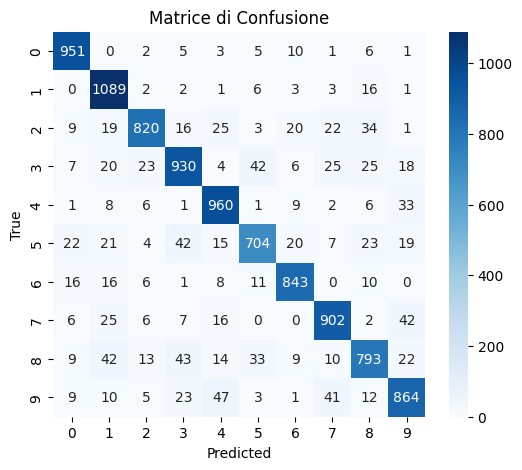

In [92]:
# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matrice di Confusione')
plt.show()


In [93]:
#sparsità

sparsity = (np.sum(model.coef_==0)/model.coef_.size) *100
print(f"Sparsity: {sparsity}")

Sparsity: 10.204081632653061


In [94]:
print(model.coef_)
weights = np.copy(model.coef_)
scale = np.abs(weights).max()
print(scale)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
0.09666234544827647


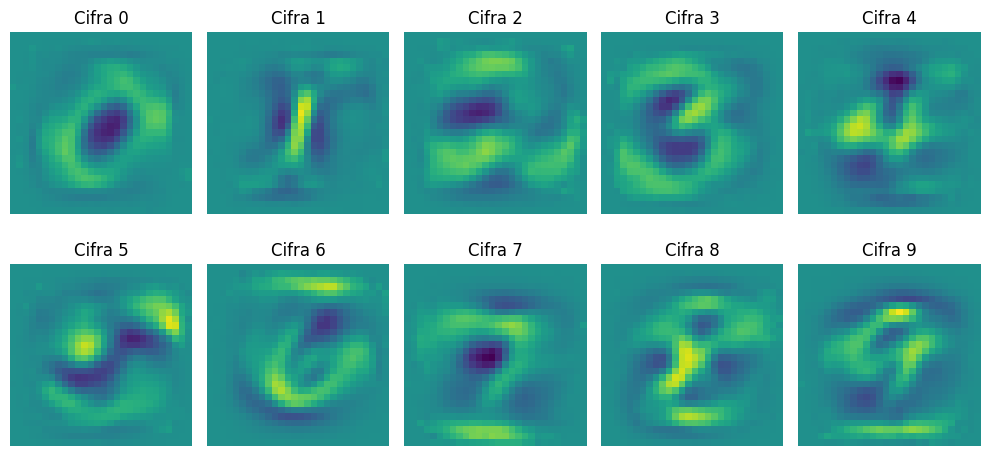

In [95]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # 2 righe, 5 colonne
axes = axes.ravel()  # per iterare facilmente

for i in range(10):
    axes[i].imshow(weights[i].reshape(28, 28), cmap='viridis', vmin=-scale, vmax=scale)
    axes[i].set_title(f"Cifra {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

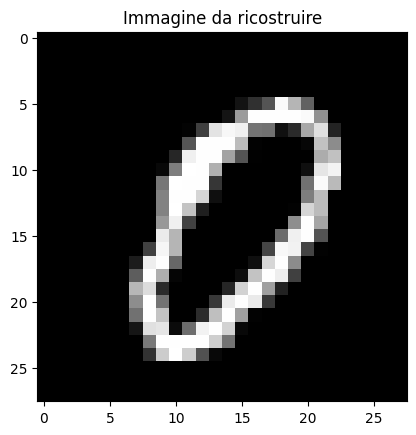

PCA(n_components=100)


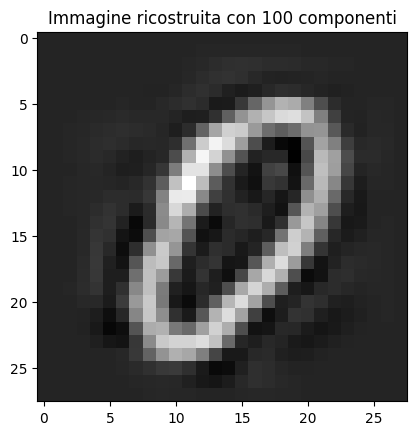

In [96]:
#PCA sui dati
from sklearn.decomposition import PCA

img_idx = 22#indice dell'immagine che ricostruisco

X_example = X.iloc[img_idx].to_numpy().reshape(28, 28) #serve una matrice 28x28 e il dato è in panda

plt.imshow(X_example, cmap='gray')
plt.title("Immagine da ricostruire")
plt.show()
 
#PCA con n componenti per ricreare l'immagine
n_components = 100
pca = PCA(n_components=n_components)
print(pca)

# Fit e trasformazione
X_pca = pca.fit_transform(X)

# Ricostruire l'immagine usando solo le prime 50 componenti
X_reconstructed = pca.inverse_transform(X_pca)
reconstructed_image = X_reconstructed[img_idx].reshape(28, 28)

plt.imshow(reconstructed_image, cmap='gray')
plt.title(f"Immagine ricostruita con {n_components} componenti")
plt.show()

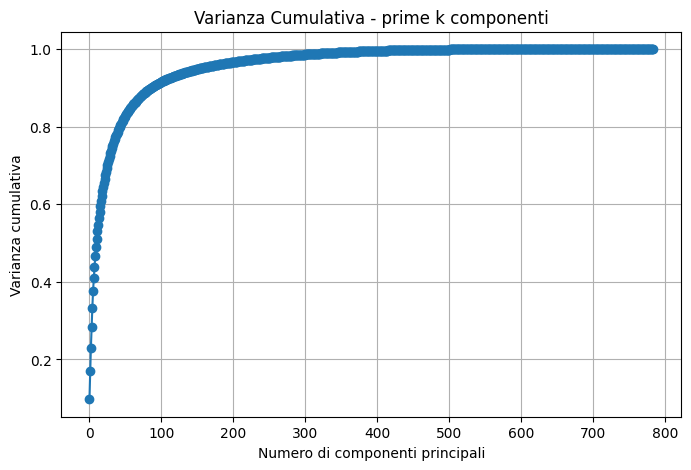

In [97]:
pca = PCA()
X_pca = pca.fit_transform(X)

# Varianza spiegata cumulativa
explained_variance_cumulative = np.cumsum(pca.explained_variance_ratio_)

# Visualizzare la varianza spiegata dalle prime k componenti
plt.figure(figsize=(8,5))
plt.plot(explained_variance_cumulative, marker='o')
plt.xlabel("Numero di componenti principali")
plt.ylabel("Varianza cumulativa")
plt.title("Varianza Cumulativa - prime k componenti")
plt.grid(True)
plt.show()

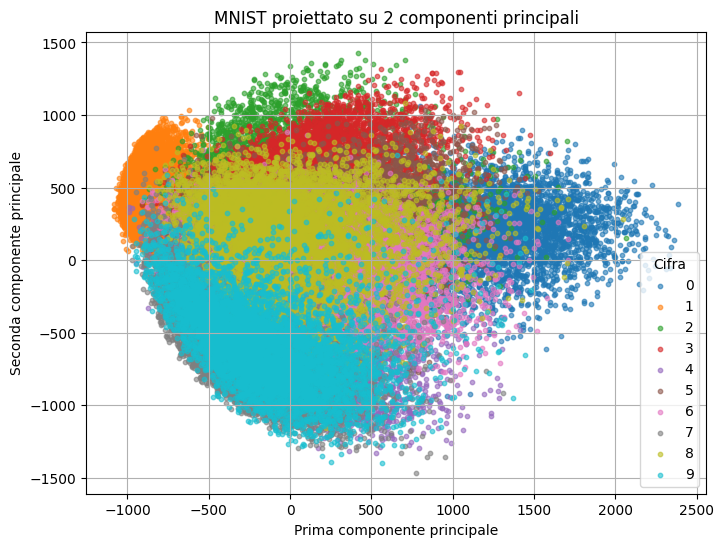

In [98]:
# PCA a 2 componenti
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(8,6))

# Colori distinti per ogni cifra
colors = plt.cm.tab10(np.arange(10))  # tab10 ha 10 colori distinti

for i in range(10):
    plt.scatter(
        X_pca_2d[y==i, 0], X_pca_2d[y==i, 1],
        color=colors[i],
        alpha=0.6,
        s=10,
        label=str(i)  # etichetta della cifra
    )

plt.xlabel("Prima componente principale")
plt.ylabel("Seconda componente principale")
plt.title("MNIST proiettato su 2 componenti principali")
plt.legend(title="Cifra") 
plt.grid(True)
plt.show()

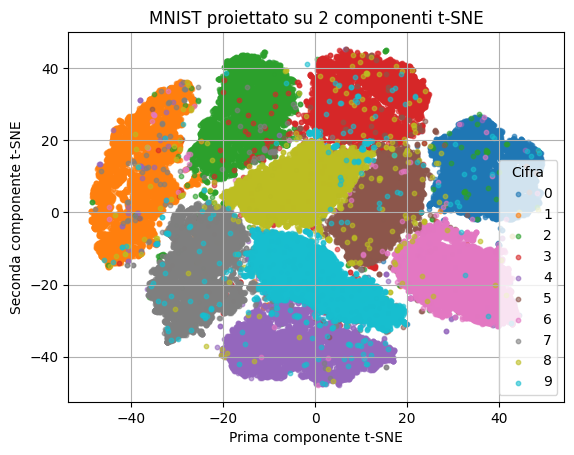

In [101]:
from sklearn.manifold import TSNE

pca_50= PCA(n_components=50) # riduco prima a 50 dimensioni per velocizzare t-SNE
X_pca_50 = pca_50.fit_transform(X)

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=500,
    method="barnes_hut",
    random_state=42
)

X_tsne_2d = tsne_2d.fit_transform(X_pca_50)

# Colori distinti per ogni cifra
colors = plt.cm.tab10(np.arange(10))  # tab10 ha 10 colori distinti

for i in range(10):
    plt.scatter(
        X_tsne_2d[y==i, 0], X_tsne_2d[y==i, 1],
        color=colors[i],
        alpha=0.6,
        s=10,
        label=str(i)  # etichetta della cifra
    )

plt.xlabel("Prima componente t-SNE")
plt.ylabel("Seconda componente t-SNE")
plt.title("MNIST proiettato su 2 componenti t-SNE")
plt.legend(title="Cifra") 
plt.grid(True)
plt.show()